In [3]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}@{os.getenv('DB_HOST')}:5432/{os.getenv('DB_NAME')}"
)


<Axes: title={'center': 'Daily Listening Volume'}, xlabel='collection_date'>

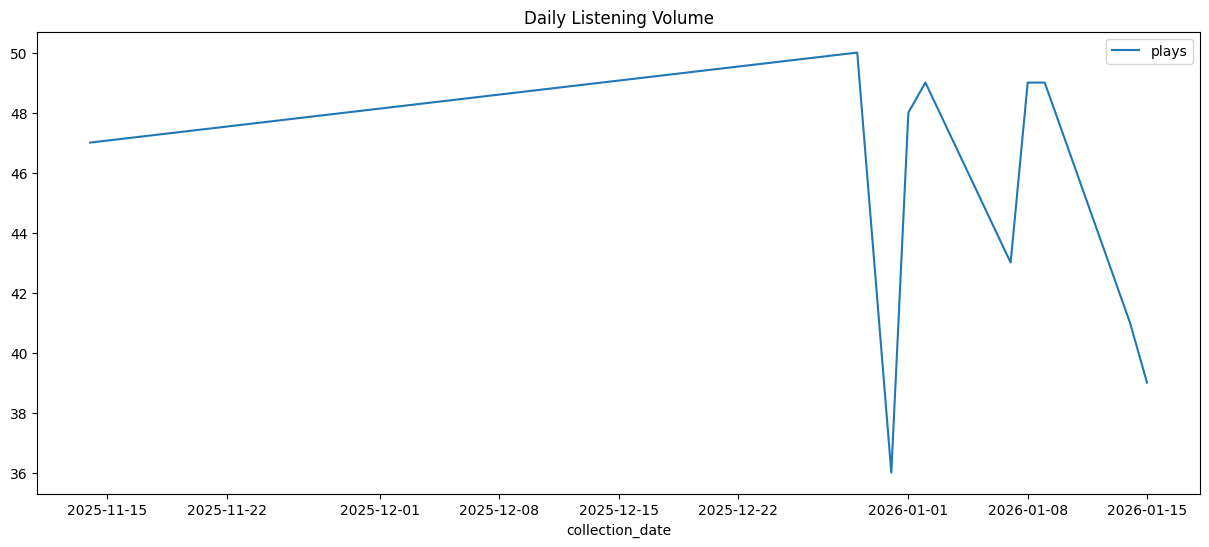

In [5]:
df = pd.read_sql("""
SELECT collection_date, COUNT(*) AS plays
FROM recent_tracks
GROUP BY collection_date
ORDER BY collection_date
""", engine)

df.plot(x="collection_date", y="plays", title="Daily Listening Volume", figsize=(15, 6))

<Axes: title={'center': 'Daily Listening Volume'}, xlabel='artist_name'>

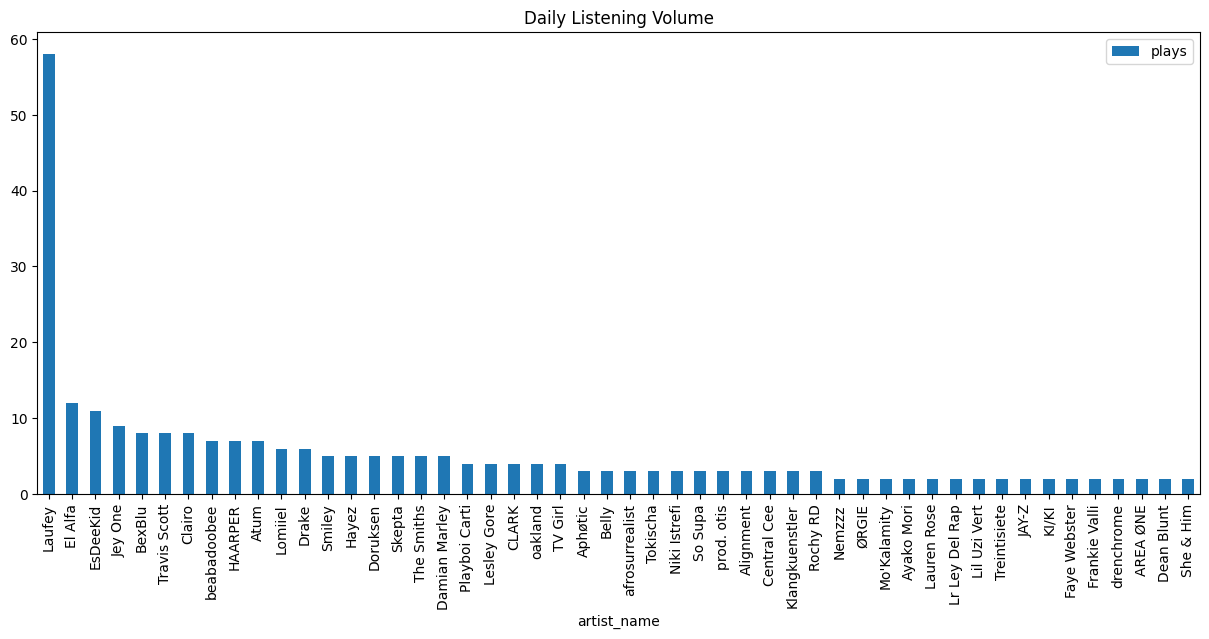

In [9]:
df = pd.read_sql("""
SELECT artist_name, COUNT(*) AS plays
FROM recent_tracks
GROUP BY artist_name
ORDER BY plays DESC
LIMIT 50;
""", engine)

df.plot(x="artist_name", y="plays", title="Daily Listening Volume", figsize=(15, 6), kind="bar")

acousticness        0.215308
danceability        0.701779
energy              0.635881
instrumentalness    0.069949
liveness             0.17978
speechiness         0.131954
valence             0.482899
tempo                    NaN
dtype: object

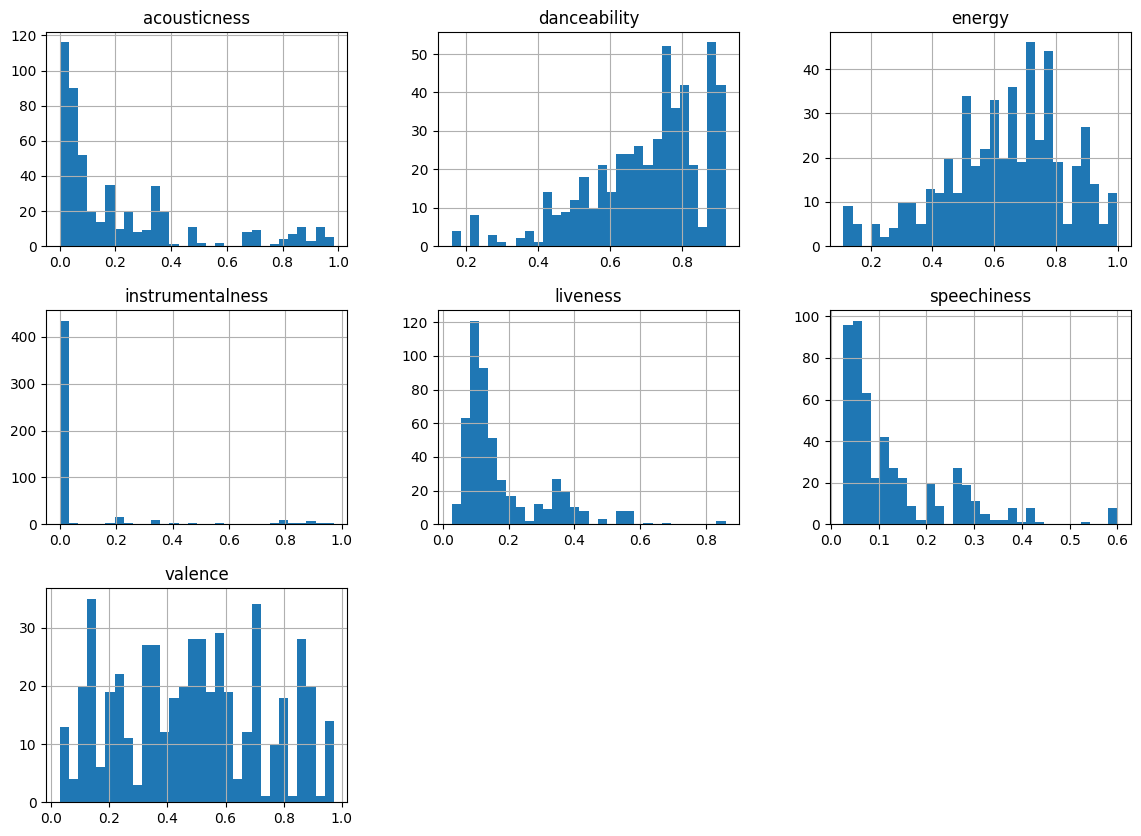

In [18]:
features = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness",
    "speechiness", "valence", "tempo"
]

df = pd.read_sql("""
SELECT * FROM recent_tracks_audio_features;
""", engine)

df[features].hist(bins=30, figsize=(14,10))
df[features].corr().round(2)
df[features].mean()


,acousticness,danceability,energy,instrumentalness,liveness,speechiness,valence,temp
acousticness,1.00,-0.17,-0.53,-0.23,-0.08,0.09,0.11,NaN
danceability,-0.17,1.00,-0.03,-0.24,-0.06,0.20,0.42,NaN
energy,-0.53,-0.03,1.00,0.43,0.15,-0.08,0.05,NaN
instrumentalness,-0.23,-0.24,0.43,1.00,-0.03,-0.21,-0.39,NaN
liveness,-0.08,-0.06,0.15,-0.03,1.00,0.11,0.07,NaN
speechiness,0.09,0.20,-0.08,-0.21,0.11,1.00,0.24,NaN
valence,0.11,0.42,0.05,-0.39,0.07,0.24,1.00,NaN
temp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


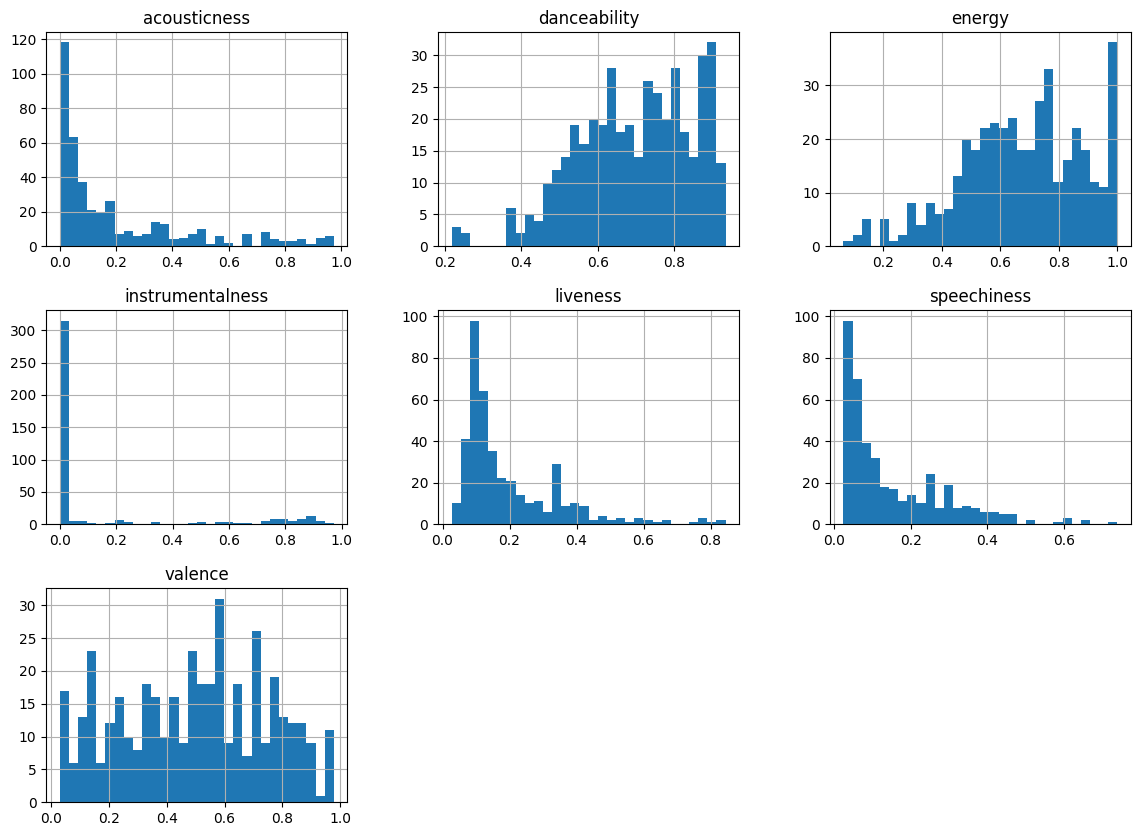

In [14]:
features = [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness",
    "speechiness", "valence", "temp"
]

df = pd.read_sql("""
SELECT * FROM top_tracks_audio_features;
""", engine)

df[features].hist(bins=30, figsize=(14,10))
df[features].corr().round(2)